# Risk Parity

In [ ]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.optimize as sco


# Load market configuration
with open("../../markets.json", "r") as f:
    config = json.load(f)

name = list(config["markets"].keys())[0]
BASE = Path("../../data")


INITIAL_INVESTMENT = config["initial_investment"]
MONTHLY_INVESTMENT = config["monthly_investment"]

In [17]:
LOOKBACK   = 36      # months of history used for rolling weights
VOL_TARGET = 0.10    # 10% annual vol target — how Bridgewater/AQR operate
REBAL_THRESHOLD = 0.05  # only rebalance if any weight drifts >5% from target

CRISES = [
    ("2008-09", "2009-06", "GFC"),
    ("2020-02", "2020-04", "COVID"),
    ("2022-01", "2022-12", "Rate Hikes"),
]
PALETTE = {
    "Equal Weight"      : "#028090",
    "Naive RP"          : "#F6C90E",
    "ERC RP (static)"   : "#38A169",
    "ERC RP (rolling)"  : "#E53E3E",
}
plt.rcParams.update({
    "figure.facecolor" : "#F4F7FB",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.4,
    "grid.color"       : "#CBD5E0",
    "font.family"      : "sans-serif",
})

print(f"Market  : {name}")
print(f"Lookback: {LOOKBACK} months")
print(f"Vol tgt : {VOL_TARGET*100:.0f}%  |  Rebal threshold: {REBAL_THRESHOLD*100:.0f}%")

Market  : primary_total_market
Lookback: 36 months
Vol tgt : 10%  |  Rebal threshold: 5%


In [18]:
rets = pd.read_csv(
    BASE / f"{name}_returns_monthly.csv",
    index_col=0, parse_dates=True
)

ASSETS = list(rets.columns)
N      = len(ASSETS)

print(f"Period : {rets.index[0].date()} -> {rets.index[-1].date()}")
print(f"Assets : {ASSETS}")
print(f"Months : {len(rets)}")

Period : 2007-05-01 -> 2025-12-01
Assets : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
Months : 224


In [19]:
# ── Cell 3: Rolling Risk-Free Rate ────────────────────────────────────────────
# Loads the actual monthly 3-month T-bill rate saved by main.ipynb.
# This is more realistic than a fixed constant because the rate went from
# near 0% in 2010-2015 to over 5% in 2022-2023.

risk_free_file = BASE / "risk_free_monthly.csv"

if risk_free_file.exists():
    risk_free_data         = pd.read_csv(risk_free_file, index_col=0, parse_dates=True)
    risk_free_data         = risk_free_data.reindex(rets.index, method="ffill")
    annual_rf_series       = risk_free_data["rf_annual"]
    monthly_rf_series      = risk_free_data["rf_monthly"]
    avg_annual_risk_free   = annual_rf_series.mean()
    avg_monthly_risk_free  = monthly_rf_series.mean()
    print(f"Rolling RF loaded  : {len(risk_free_data)} months")
    print(f"  Range  : {annual_rf_series.min()*100:.2f}% – {annual_rf_series.max()*100:.2f}%")
    print(f"  Average: {avg_annual_risk_free*100:.3f}% annual")
else:
    print("WARNING: risk_free_monthly.csv not found. Run main.ipynb first.")
    print("Falling back to fixed 3.51% annual rate.")
    avg_annual_risk_free  = 0.0351
    avg_monthly_risk_free = (1 + avg_annual_risk_free) ** (1/12) - 1
    annual_rf_series      = pd.Series(avg_annual_risk_free,  index=rets.index)
    monthly_rf_series     = pd.Series(avg_monthly_risk_free, index=rets.index)

Rolling RF loaded  : 224 months
  Range  : 0.01% – 5.34%
  Average: 1.415% annual


In [20]:
# ── Cell 4: Static Weights — Textbook Baseline ───────────────────────────────
# These are the classic academic implementations.
# Both use the FULL return history — no rolling window.
# Useful as a textbook reference but NOT how real platforms operate.
# The rolling version in Cell 5 is the realistic one.

# Equal Weight
equal_weights = pd.Series(1 / N, index=ASSETS)

# Naive Risk Parity — inverse volatility, ignores correlations
asset_volatility    = rets.std()
inverse_volatility  = 1 / asset_volatility
naive_weights       = inverse_volatility / inverse_volatility.sum()

In [21]:
def compute_erc_weights(returns):
    """
    Find weights where every asset contributes equally to portfolio risk.

    Steps:
      1. Compute the covariance matrix from return history
      2. For any set of weights, compute each asset's risk contribution
      3. Minimize the differences between all risk contributions
      4. When all contributions are equal, we have ERC weights
    """
    cov = returns.cov().values          # full covariance matrix (numpy)
    num_assets = cov.shape[0]

    def risk_contributions(weights):
        portfolio_variance = weights @ cov @ weights
        port_vol = np.sqrt(portfolio_variance)
        marginal_risk = (cov @ weights) / port_vol      
        total_risk_contribution = weights * marginal_risk                    
        return total_risk_contribution

    def objective(w):
        risk_contrib = risk_contributions(w)
        return sum((risk_contrib[i] - risk_contrib[j])**2
                   for i in range(num_assets)
                   for j in range(num_assets))
    
    result = sco.minimize(
        objective,
        x0          = np.ones(num_assets) / num_assets,
        method      = "SLSQP",
        bounds      = [(0, 1)] * num_assets,
        constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        options     = {"ftol": 1e-12, "maxiter": 1000}
    )
    return pd.Series(result.x, index=returns.columns)

    

In [22]:
erc_weights_static = compute_erc_weights(rets)

# Verify: check that risk contributions are actually equal
covariance_full          = rets.cov().values
portfolio_volatility     = np.sqrt(erc_weights_static.values @ covariance_full @ erc_weights_static.values)
marginal_risk            = (covariance_full @ erc_weights_static.values) / portfolio_volatility
total_risk_contributions = erc_weights_static.values * marginal_risk
risk_contribution_pct    = pd.Series(
    total_risk_contributions / total_risk_contributions.sum() * 100,
    index=ASSETS
)

print("ERC static weights (%):")
print((erc_weights_static * 100).round(2).to_string())
print(f"\nRisk contributions — should all be ~{100/N:.1f}%:")
print(risk_contribution_pct.round(3).to_string())

ERC static weights (%):
BND    30.18
GLD    11.75
TIP    23.56
TLT    14.02
VEU     9.99
VGT    10.51

Risk contributions — should all be ~16.7%:
BND    16.667
GLD    16.667
TIP    16.667
TLT    16.667
VEU    16.667
VGT    16.667


In [23]:
# ── Cell 5: Rolling ERC — The Realistic Simulation ───────────────────────────
# Every month we:
#   1. Look back 36 months and recompute ERC weights from that window only
#   2. Apply volatility targeting — scale so portfolio hits 10% annual vol
#   3. Check if weights have drifted enough to warrant rebalancing (>5% drift)
#   4. Invest the next month using those weights
#   5. Record the return and move forward
#
# This is how real platforms work — they never use future data.

rolling_weight_history  = []
rolling_return_history  = []
rolling_date_history    = []
monthly_turnover        = []

current_weights = np.ones(N) / N  # start at equal weight

for month_index in range(LOOKBACK, len(rets)):
    # Use only the past 36 months — no future data
    return_window = rets.iloc[month_index - LOOKBACK : month_index]

    # Step 1: compute ERC weights from this window
    try:
        new_target_weights = compute_erc_weights(return_window).values
    except Exception:
        new_target_weights = np.ones(N) / N

    # Step 2: volatility targeting
    # Scale weights so the portfolio hits VOLATILITY_TARGET (10% annual)
    window_covariance    = return_window.cov().values
    portfolio_volatility = np.sqrt(new_target_weights @ window_covariance @ new_target_weights)
    annualized_vol       = portfolio_volatility * np.sqrt(12)

    if annualized_vol > 0:
        scaling_factor     = min(VOL_TARGET / annualized_vol, 2.0)
        new_target_weights = new_target_weights * scaling_factor
        # Renormalize — any remainder implicitly goes to cash
        new_target_weights = new_target_weights / new_target_weights.sum()

    # Step 3: rebalancing threshold
    # Only trade if any weight has drifted more than REBALANCE_THRESHOLD from target
    weight_drift = np.abs(current_weights - new_target_weights)
    if weight_drift.max() > REBAL_THRESHOLD:
        trade_volume    = weight_drift.sum()   # total weight traded this month
        current_weights = new_target_weights
    else:
        trade_volume = 0.0   # no rebalancing needed this month

    monthly_turnover.append(trade_volume)

    # Step 4: earn next month's return using current weights
    next_month_return = current_weights @ rets.iloc[month_index].values
    rolling_return_history.append(next_month_return)
    rolling_date_history.append(rets.index[month_index])
    rolling_weight_history.append(current_weights.copy())

    # Step 5: let weights drift naturally from this month's rets
    ending_values   = current_weights * (1 + rets.iloc[month_index].values)
    current_weights = ending_values / ending_values.sum()


rolling_weights_df  = pd.DataFrame(rolling_weight_history,
                                    index=rolling_date_history, columns=ASSETS)
rolling_returns     = pd.Series(rolling_return_history, index=rolling_date_history)
turnover_series     = pd.Series(monthly_turnover,        index=rolling_date_history)

# All static returns aligned to the same period for fair comparison
comparison_period = rolling_returns.index

print(f"Rolling ERC done — {len(rolling_returns)} months simulated")
print(f"Months rebalanced        : {(turnover_series > 0).sum()} / {len(turnover_series)}")
print(f"Average monthly turnover : {turnover_series.mean()*100:.2f}%")

Rolling ERC done — 188 months simulated
Months rebalanced        : 12 / 188
Average monthly turnover : 1.13%


In [24]:
# ── Cell 6: Align Static Returns to Comparison Period ────────────────────────
# Trim all static strategies to the same date range as rolling ERC.
# This ensures every chart and number is comparing the same time window.

equal_weight_returns    = (rets * equal_weights).sum(axis=1).loc[comparison_period]
naive_rp_returns        = (rets * naive_weights).sum(axis=1).loc[comparison_period]
erc_static_returns      = (rets * erc_weights_static).sum(axis=1).loc[comparison_period]

all_strategies = {
    "Equal Weight"     : equal_weight_returns,
    "Naive RP"         : naive_rp_returns,
    "ERC RP (static)"  : erc_static_returns,
    "ERC RP (rolling)" : rolling_returns,
}

print(f"Comparison period : {comparison_period[0].date()} -> {comparison_period[-1].date()}")
print(f"Months            : {len(comparison_period)}")

Comparison period : 2010-05-01 -> 2025-12-01
Months            : 188


In [25]:
# ── Cell 7: Performance Summary ──────────────────────────────────────────────

def compute_performance_stats(monthly_returns, strategy_label):
    annualized_return     = monthly_returns.mean() * 12 * 100
    annualized_volatility = monthly_returns.std() * np.sqrt(12) * 100
    # Sharpe ratio: excess return over risk-free rate, per unit of volatility
    sharpe_ratio          = (
        (monthly_returns.mean() - avg_monthly_risk_free) * 12
        / (monthly_returns.std() * np.sqrt(12))
    )
    cumulative_value      = (1 + monthly_returns).cumprod()
    rolling_peak          = cumulative_value.cummax()
    drawdown_series       = (cumulative_value - rolling_peak) / rolling_peak
    max_drawdown          = drawdown_series.min() * 100

    return pd.Series({
        "Ann. Return %"  : round(annualized_return,     2),
        "Ann. Vol %"     : round(annualized_volatility, 2),
        "Sharpe Ratio"   : round(sharpe_ratio,          3),
        "Max Drawdown %" : round(max_drawdown,          2),
    }, name=strategy_label)


summary_table = pd.DataFrame([
    compute_performance_stats(returns_series, label)
    for label, returns_series in all_strategies.items()
])

print("── Performance Summary ──")
print(summary_table.to_string())

── Performance Summary ──
                  Ann. Return %  Ann. Vol %  Sharpe Ratio  Max Drawdown %
Equal Weight               7.46        8.09         0.750          -21.17
Naive RP                   5.20        6.30         0.604          -18.27
ERC RP (static)            5.78        6.73         0.651          -19.12
ERC RP (rolling)           6.27        6.59         0.740          -18.86


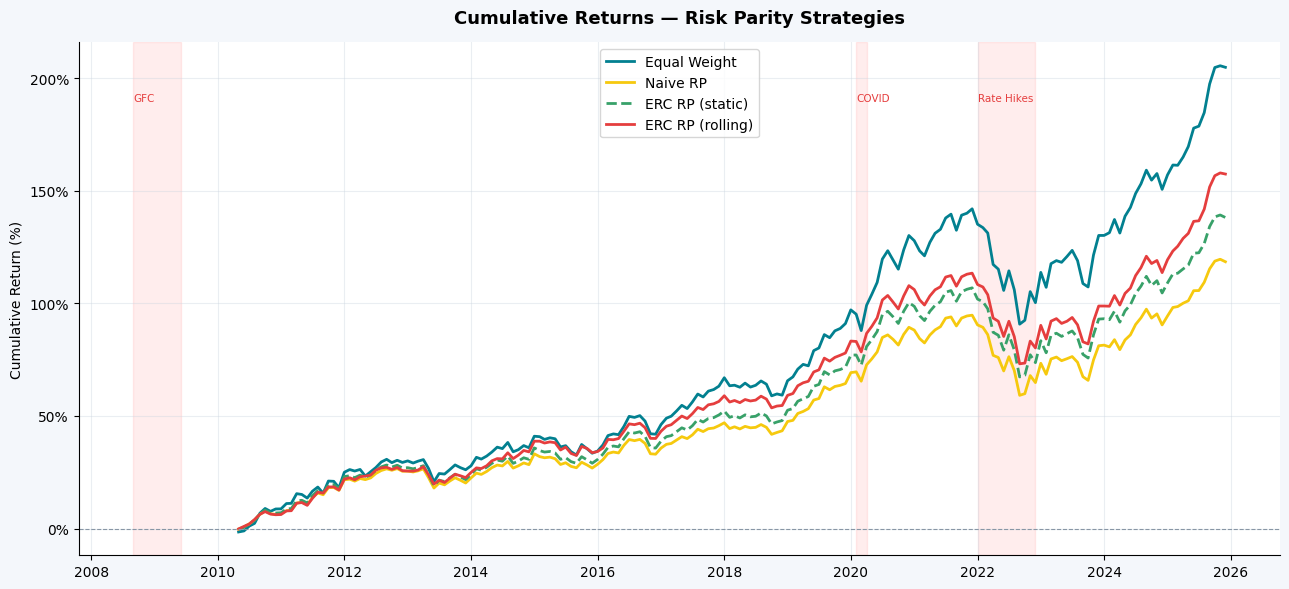

In [26]:
# ── Cell 8: Cumulative Returns ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 6))

for label, monthly_returns in all_strategies.items():
    cumulative_growth_pct = ((1 + monthly_returns).cumprod() - 1) * 100
    ax.plot(cumulative_growth_pct, label=label,
            color=PALETTE[label], linewidth=2,
            linestyle="--" if "static" in label else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Returns — Risk Parity Strategies",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Cumulative Return (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

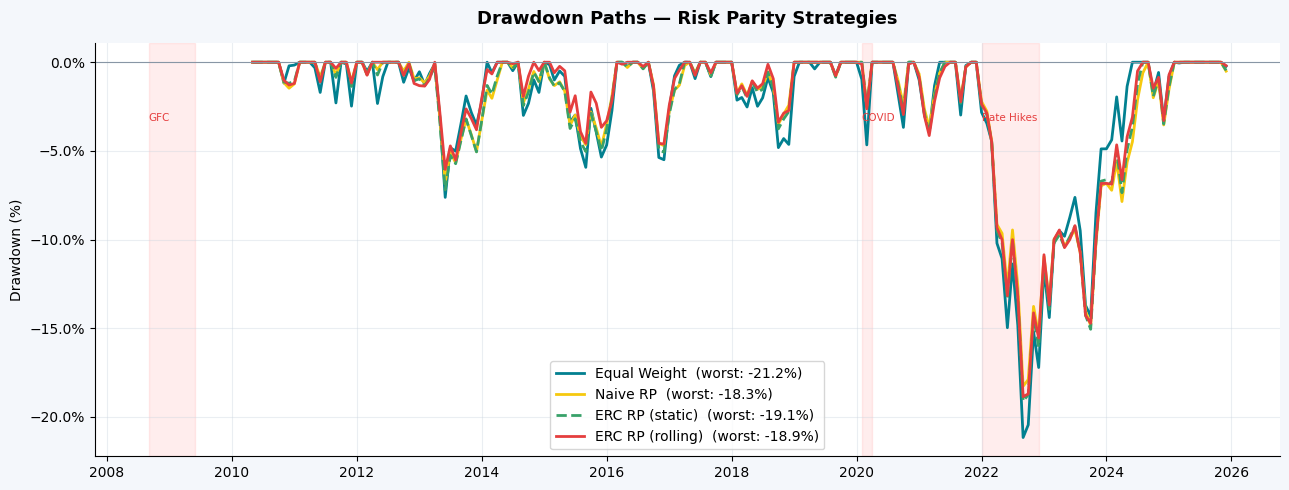

In [28]:
# ── Cell 9: Drawdown Paths ────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    cumulative_value = (1 + monthly_returns).cumprod()
    rolling_peak     = cumulative_value.cummax()
    drawdown_pct     = ((cumulative_value - rolling_peak) / rolling_peak) * 100
    ax.plot(drawdown_pct,
            label=f"{label}  (worst: {drawdown_pct.min():.1f}%)",
            color=PALETTE[label], linewidth=2,
            linestyle="--" if "static" in label else "-")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_min = ax.get_ylim()[0]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_min * 0.15,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.axhline(0, color="#8896A5", linewidth=0.8)
ax.set_title("Drawdown Paths — Risk Parity Strategies",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

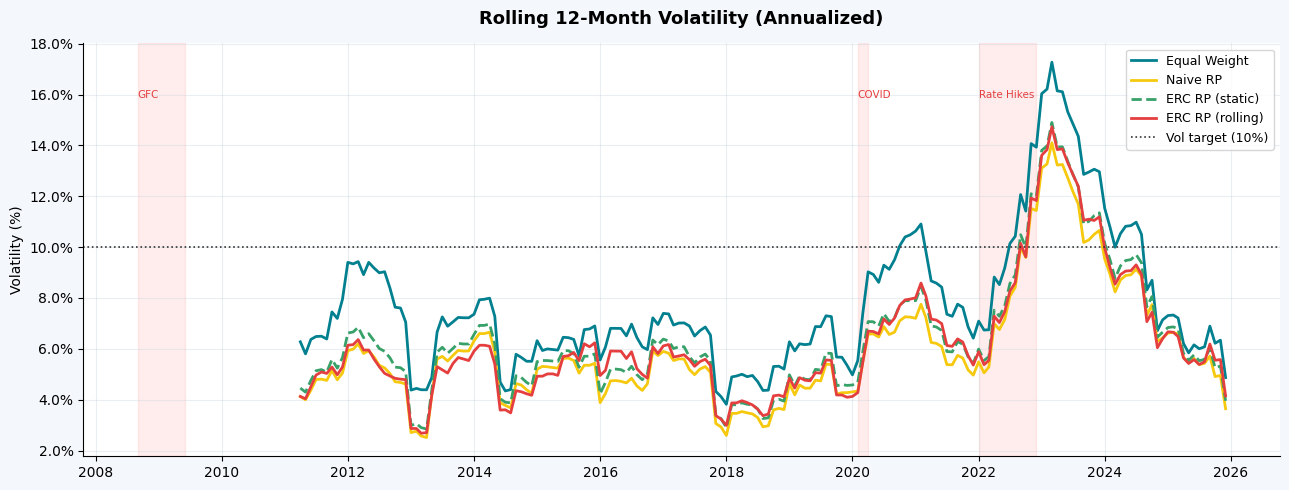

In [29]:
# ── Cell 10: Rolling 12-Month Volatility ─────────────────────────────────────
# ERC rolling should stay closest to the 10% target line.
# That's the whole point of volatility targeting.

rolling_window_months = 12

fig, ax = plt.subplots(figsize=(13, 5))

for label, monthly_returns in all_strategies.items():
    rolling_vol_annualized = monthly_returns.rolling(rolling_window_months).std() \
                             * np.sqrt(12) * 100
    ax.plot(rolling_vol_annualized, label=label,
            color=PALETTE[label], linewidth=2,
            linestyle="--" if "static" in label else "-")

ax.axhline(VOL_TARGET * 100, color="#333", linewidth=1.2,
           linestyle=":", label=f"Vol target ({VOL_TARGET*100:.0f}%)")

for crisis_start, crisis_end, crisis_label in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.07, color="red")
y_max = ax.get_ylim()[1]
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), y_max * 0.88,
            crisis_label, fontsize=7.5, color="#E53E3E")

ax.set_title(f"Rolling {rolling_window_months}-Month Volatility (Annualized)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Volatility (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [30]:
# ── Cell 11: Recovery Dynamics ────────────────────────────────────────────────
# How many months did each strategy take to recover from each crisis?
# Measured from the worst point (trough) back to the pre-crash peak.

def months_to_recover(monthly_returns, crisis_start, crisis_end):
    cumulative_value  = (1 + monthly_returns).cumprod()
    pre_crisis_values = cumulative_value.loc[:crisis_start]
    if pre_crisis_values.empty:
        return None
    pre_crisis_peak   = pre_crisis_values.max()
    crisis_values     = cumulative_value.loc[crisis_start:crisis_end]
    if crisis_values.empty:
        return None
    trough_date       = crisis_values.idxmin()
    post_trough       = cumulative_value.loc[trough_date:]
    recovered_months  = post_trough[post_trough >= pre_crisis_peak]
    if recovered_months.empty:
        return None
    recovery_date     = recovered_months.index[0]
    months_elapsed    = len(cumulative_value.loc[trough_date:recovery_date]) - 1
    return months_elapsed


print("── Recovery Time (months from trough back to pre-crisis peak) ──\n")
header = f"{'Crisis':<16}" + "".join(f"{label:>20}" for label in all_strategies)
print(header)
print("-" * len(header))

for crisis_start, crisis_end, crisis_label in CRISES:
    row = f"{crisis_label:<16}"
    for label, monthly_returns in all_strategies.items():
        months = months_to_recover(monthly_returns, crisis_start, crisis_end)
        row += f"{'Not recovered':>20}" if months is None else f"{months} months".rjust(20)
    print(row)

── Recovery Time (months from trough back to pre-crisis peak) ──

Crisis                  Equal Weight            Naive RP     ERC RP (static)    ERC RP (rolling)
------------------------------------------------------------------------------------------------
GFC                    Not recovered       Not recovered       Not recovered       Not recovered
COVID                       1 months            1 months            1 months            1 months
Rate Hikes                 21 months           24 months           23 months           23 months


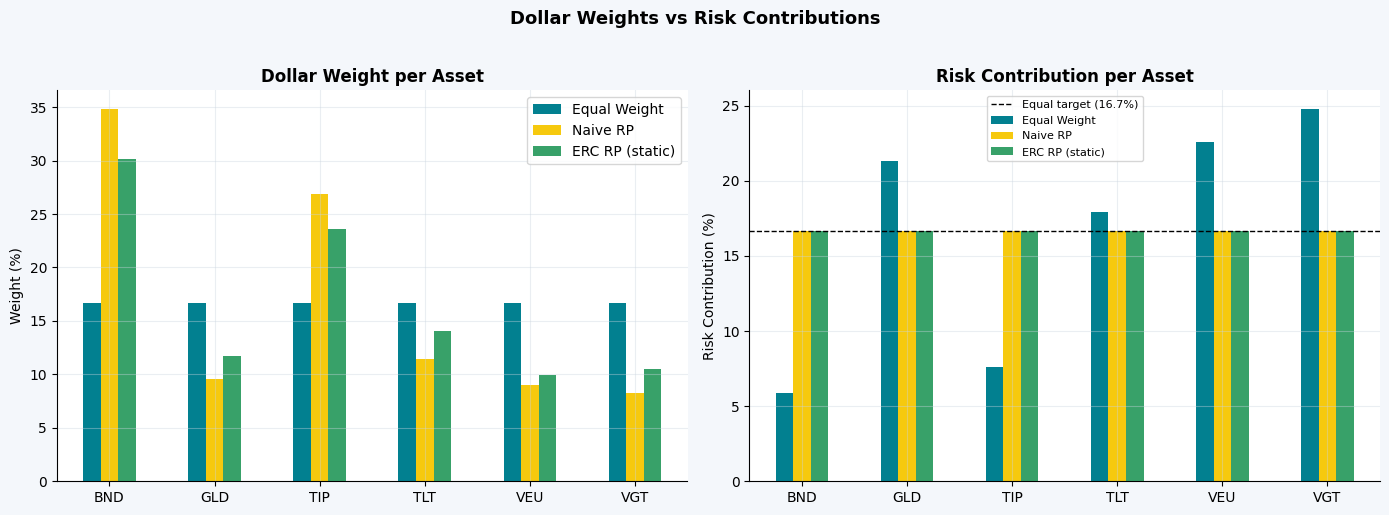

In [31]:
# ── Cell 12: Weight Allocation vs Risk Contribution ──────────────────────────
# Left chart: what percentage each asset gets in terms of dollars
# Right chart: what percentage each asset contributes in terms of risk
# ERC makes the right chart equal — the left chart will not be equal

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: dollar weight allocation ───────────────────────────────────────────
ax = axes[0]
weight_comparison = pd.DataFrame({
    "Equal Weight"    : equal_weights * 100,
    "Naive RP"        : naive_weights * 100,
    "ERC RP (static)" : erc_weights_static * 100,
})
weight_comparison.plot(kind="bar", ax=ax,
                       color=["#028090", "#F6C90E", "#38A169"])
ax.set_title("Dollar Weight per Asset", fontweight="bold")
ax.set_ylabel("Weight (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)

# ── Right: risk contribution ──────────────────────────────────────────────────
ax = axes[1]
equal_weight_risk_contribution = (equal_weights * asset_volatility) / \
                                  (equal_weights * asset_volatility).sum() * 100
naive_rp_risk_contribution     = (naive_weights * asset_volatility) / \
                                  (naive_weights * asset_volatility).sum() * 100

risk_contribution_comparison = pd.DataFrame({
    "Equal Weight"    : equal_weight_risk_contribution,
    "Naive RP"        : naive_rp_risk_contribution,
    "ERC RP (static)" : risk_contribution_pct,
})
risk_contribution_comparison.plot(kind="bar", ax=ax,
                                   color=["#028090", "#F6C90E", "#38A169"])
ax.axhline(100 / N, color="black", linewidth=1, linestyle="--",
           label=f"Equal target ({100/N:.1f}%)")
ax.set_title("Risk Contribution per Asset", fontweight="bold")
ax.set_ylabel("Risk Contribution (%)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8)

fig.suptitle("Dollar Weights vs Risk Contributions",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

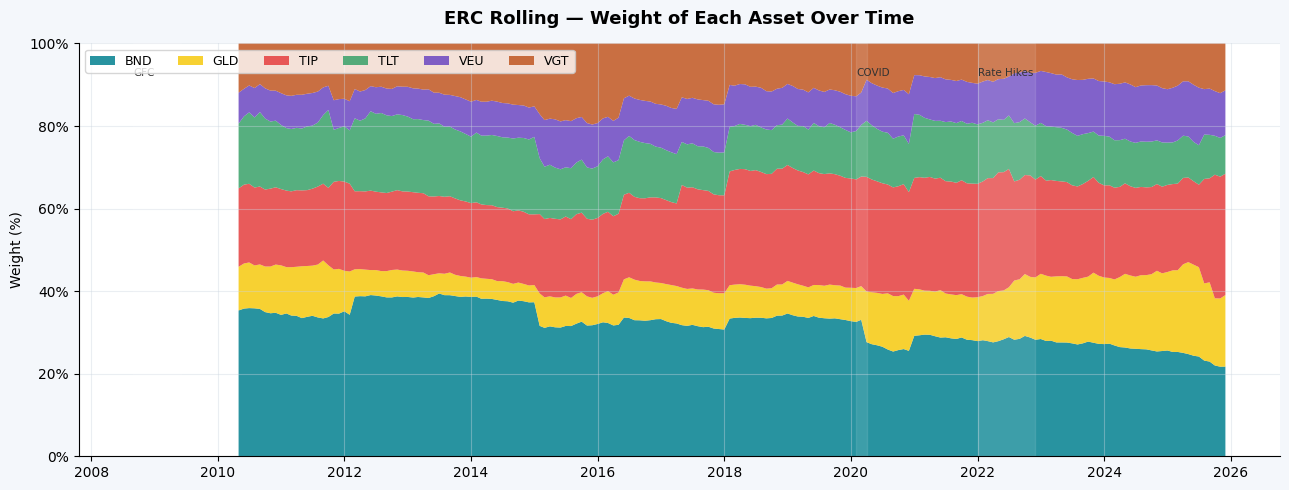

In [32]:
# ── Cell 13: Rolling ERC Weight Evolution ─────────────────────────────────────
# Shows how each asset's weight changes month by month as volatility shifts.
# In calm periods weights are more equal.
# In volatile periods (GFC, 2022) high-risk assets shrink automatically.

asset_colors = ["#028090", "#F6C90E", "#E53E3E", "#38A169", "#6B46C1", "#C05621"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(
    rolling_weights_df.index,
    [rolling_weights_df[asset] * 100 for asset in ASSETS],
    labels=asset_colors, colors=asset_colors, alpha=0.85
)
# Replot with correct labels
ax.cla()
ax.stackplot(
    rolling_weights_df.index,
    [rolling_weights_df[asset] * 100 for asset in ASSETS],
    labels=ASSETS, colors=asset_colors, alpha=0.85
)

for crisis_start, crisis_end, _ in CRISES:
    ax.axvspan(pd.Timestamp(crisis_start), pd.Timestamp(crisis_end),
               alpha=0.10, color="white", zorder=2)
for crisis_start, _, crisis_label in CRISES:
    ax.text(pd.Timestamp(crisis_start), 92,
            crisis_label, fontsize=7.5, color="#333")

ax.set_title("ERC Rolling — Weight of Each Asset Over Time",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylabel("Weight (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, ncol=N, loc="upper left")
plt.tight_layout()
plt.show()

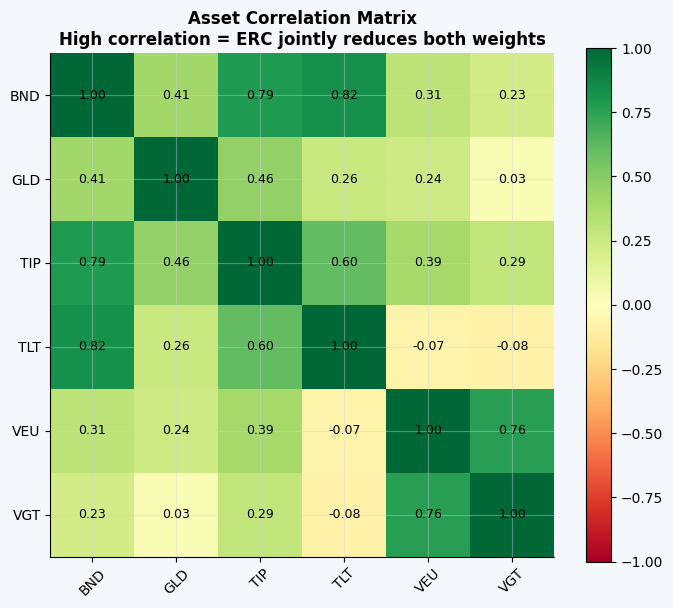

In [33]:
# ── Cell 14: Correlation Heatmap ─────────────────────────────────────────────
# Shows why ERC and Naive RP produce different weights.
# When two assets are highly correlated their risks overlap.
# ERC penalizes both — Naive RP treats them as independent and misses this.

correlation_matrix = rets.corr()

fig, ax = plt.subplots(figsize=(7, 6))
heatmap = ax.imshow(correlation_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(heatmap, ax=ax)

tick_positions = range(N)
ax.set_xticks(tick_positions)
ax.set_xticklabels(ASSETS, rotation=45)
ax.set_yticks(tick_positions)
ax.set_yticklabels(ASSETS)

for row in range(N):
    for col in range(N):
        ax.text(col, row, f"{correlation_matrix.iloc[row, col]:.2f}",
                ha="center", va="center", fontsize=9)

ax.set_title("Asset Correlation Matrix\n"
             "High correlation = ERC jointly reduces both weights",
             fontweight="bold")
plt.tight_layout()
plt.show()